# Assignment 5

## Gradient Decent and SGD

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-05-05

Course: Deep Machine Learning 4DT908

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
np.random.seed(1)


def mse(ws, m, X, Y):
    Y_pred = np.array([m(ws, xi) for xi in X])
    return np.mean((Y - Y_pred) ** 2)


def grad_mse(ws, m, grads, X, Y):
    N = len(X)
    M = len(ws)
    Y_pred = np.array([m(ws, xi) for xi in X])
    residuals = Y - Y_pred
    grad_ws = np.array([
        np.dot(residuals, np.array([grads[j](ws, xi) for xi in X]))
        for j in range(M)
    ])
    return -2 / N * grad_ws


def grad_desc_mse(K, ws, learning_eps, grad_loss):
    history = [ws]

    for k in range(K):
        grad_ws = grad_loss(ws)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws

        history.append(ws)

    return ws, np.array(history)


### Scene

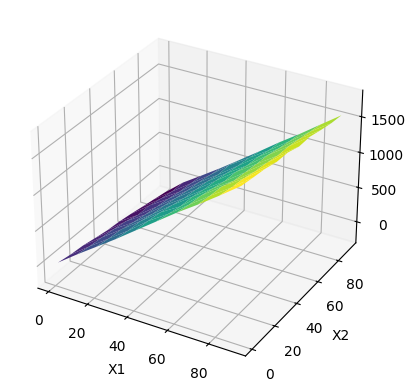

In [3]:
N = 100
XX = np.empty((N**2, 2))
i = 0
for j in range(1, N + 1):
    for k in range(1, N + 1):
        XX[i][0] = k
        XX[i][1] = j
        i += 1

a10 = 20
a20 = -3
X1 = XX[:, 0]
X2 = XX[:, 1]


def f0(x1, x2):
    return a10 * x1 + a20 * x2


def f(x1, x2, r):
    return a10 * x1 + a20 * x2 + r


def ff(x1, x2):
    return f(x1, x2, np.random.normal(0, 10))


R = np.random.normal(0, 10, N * N)

Y = np.array([f(x1, x2, r) for x1, x2, r in zip(X1, X2, R)])

x_vals = np.arange(1, N + 1, N / 10)
y_vals = np.arange(1, N + 1, N / 10)
A, B = np.meshgrid(x_vals, y_vals)

Z = np.array(
    [[ff(x1, x2) for x1, x2 in zip(row_A, row_B)] for row_A, row_B in zip(A, B)]
)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(A, B, Z, cmap="viridis")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
plt.show()

Plane generation with random noise.

In [4]:
def m1(ws, x):
    return ws[0] * x[0] + ws[1] * x[1]


def mse1(ws):
    return mse(ws, m1, XX, Y)


in_ = 2
out = 1
limit = (6 / (in_ + out)) ** 0.5
ws0 = np.random.rand(2) * 2 * limit - limit
print(f"initial weights: {ws0}")
print(f"Initial mse: {mse1(ws0)}")

initial weights: [1.07168949 0.96501769]
Initial mse: 882784.4918118204


Defining simple neural net and init random weights.

In [5]:
def grad1(ws, x):
    return x[0]


def grad2(ws, x):
    return x[1]


gradients1 = [grad1, grad2]

In [ ]:
def mse_surface(a, b):
    return mse1([a, b])


def grad_loss(ws):
    return grad_mse(ws, m1, gradients1, XX, Y)


K = 20
learning_eps = 0.00015

a_range = np.arange(min(a10, ws0[0]) - 10, max(a10, ws0[0]) + 11, 1)
b_range = np.arange(min(a20, ws0[1]) - 10, max(a20, ws0[1]) + 11, 1)
A, B = np.meshgrid(a_range, b_range)
Z = np.vectorize(mse_surface)(A, B)

start_time = time.time()
ws, history = grad_desc_mse(K, ws0, learning_eps, grad_loss)
print(
    f"Gradient descent time: {time.time() - start_time:.4f} seconds, with loss: {mse1(history[-1])}"
)

plt.contour(A, B, Z, levels=30, cmap="viridis")
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("a")
plt.ylabel("b")
plt.show()


In [ ]:
mseHistory = [mse1(ws) for ws in history]
plt.plot(range(len(mseHistory)), mseHistory)
plt.show()


Training model and showcasing loss history.

### SGD

In [ ]:
def stochastic_grad_desc_mse(K, ws, learning_eps, grad_loss, N):
    batch_size = int(N * 0.01)
    history = [ws]

    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)

        grad_ws = grad_loss(ws, randices)

        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws

        history.append(ws)

    return ws, np.array(history)


SGD with approx of gradient decent based on sample of size `batch_size` of dataset.

In [ ]:
def grad_loss2(ws, randices):
    XX_batch = XX[randices, :]
    Y_batch = Y[randices]
    return grad_mse(ws, m1, gradients1, XX_batch, Y_batch)


a_range = np.arange(min(a10, ws0[0]) - 10, max(a10, ws0[0]) + 11, 1)
b_range = np.arange(min(a20, ws0[1]) - 10, max(a20, ws0[1]) + 11, 1)
A, B = np.meshgrid(a_range, b_range)
Z = np.vectorize(mse_surface)(A, B)

start_time = time.time()
ws, history = stochastic_grad_desc_mse(K, ws0, learning_eps, grad_loss2, N * N)
print(
    f"Time elapsed: {time.time() - start_time:.4f} seconds with loss: {mse1(history[-1])}"
)
plt.contour(A, B, Z, cmap="viridis")
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("a")
plt.ylabel("b")
plt.show()


In [ ]:
mseHistory = [mse1(ws) for ws in history]
plt.plot(range(len(mseHistory)), mseHistory)
plt.show()


Same but with $time/2$ but greater loss.

### SGD adaptive LR

In [ ]:
def stochastic_adaptive_grad_desc_mse(K, ws, learning_eps, grad_loss, N, alpha):
    batch_size = int(N * 0.01)
    history = [ws]

    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)
        old_ws = ws.copy()
        ws = old_ws - learning_eps * grad_ws
        learning_eps *= 1 - alpha

        history.append(ws)

    return ws, np.array(history)


a_range = np.arange(min(a10, ws0[0]) - 10, max(a10, ws0[0]) + 11, 1)
b_range = np.arange(min(a20, ws0[1]) - 10, max(a20, ws0[1]) + 11, 1)
A, B = np.meshgrid(a_range, b_range)
Z = np.vectorize(mse_surface)(A, B)

best = [100000]
for alpha in np.arange(0.001, 0.02, 0.001):
    for learning_eps in np.arange(0.00001, 0.0001, 0.00001):
        start_time = time.time()
        ws, history = stochastic_adaptive_grad_desc_mse(
            K, ws0, learning_eps, grad_loss2, N * N, alpha
        )
        elapsed = time.time() - start_time
        final_loss = mse1(history[-1])

        if final_loss < best[0]:
            best = [final_loss, elapsed, alpha, learning_eps, ws, history]

loss, elapsed, alpha, learning_eps, ws, history = best
print(
    f"Best loss: {loss}, time: {elapsed} seconds, with alpha: {alpha:.4f} and learning rate: {learning_eps:.5f}"
)

plt.contour(A, B, Z, cmap="viridis")
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("a")
plt.ylabel("b")
plt.show()


In [ ]:
mseHistory = [mse1(ws) for ws in history]
plt.plot(range(len(mseHistory)), mseHistory)
plt.show()


SGD with Adaptive LR by $\alpha$ per iteration, due to assumption of destionation getting closer by each iter. Vary $\alpha$ and LR but loss is worse then baseline SGD.

### SGD with momentum

In [ ]:
def stochastic_momentum_grad_desc_mse(K, ws, learning_eps, grad_loss, N, momentum):
    batch_size = int(N * 0.01)
    history = [ws]
    v = np.zeros_like(ws)

    for k in range(K):
        randices = np.random.choice(N, batch_size, replace=False)
        grad_ws = grad_loss(ws, randices)

        v = momentum * v + grad_ws
        old_ws = ws.copy()
        ws = old_ws - learning_eps * v

        history.append(ws)

    return ws, np.array(history)


a_range = np.arange(min(a10, ws0[0]) - 10, max(a10, ws0[0]) + 11, 1)
b_range = np.arange(min(a20, ws0[1]) - 10, max(a20, ws0[1]) + 11, 1)
A, B = np.meshgrid(a_range, b_range)
Z = np.vectorize(mse_surface)(A, B)

best = [100000]
for momentum in np.arange(0.5, 0.99, 0.05):
    for learning_eps in np.arange(0.00001, 0.0001, 0.00001):
        start_time = time.time()
        ws, history = stochastic_momentum_grad_desc_mse(
            K, ws0, learning_eps, grad_loss2, N * N, momentum
        )
        elapsed = time.time() - start_time
        final_loss = mse1(history[-1])

        if final_loss < best[0]:
            best = [final_loss, elapsed, momentum, learning_eps, ws, history]

loss, elapsed, momentum, learning_eps, ws, history = best
print(
    f"Best loss: {loss}, time: {elapsed} seconds, with momentum: {momentum:.2f} and learning rate: {learning_eps:.5f}"
)

plt.contour(A, B, Z, cmap="viridis")
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("a")
plt.ylabel("b")
plt.show()


In [ ]:
mseHistory = [mse1(ws) for ws in history]
plt.plot(range(len(mseHistory)), mseHistory)
plt.show()


SGD with Polyak momentum $\left( v_{n+1} = \mu \cdot v_n + \nabla L \right)$, where the weight update is $w_{n+1} = w_n - \varepsilon \cdot v_{n+1}$.
A momentum coefficient $\mu \in [0, 1)$ controls how much past gradients contribute.

Improved convergence stability compared to plain SGD.
